<a href="https://colab.research.google.com/github/jumbokh/ml-class2025/blob/main/lab/example/ML_Experiment_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 本科生機器學習綜合實驗
本實驗包含隨機森林、貝氏分類、SVM 及集成學習，使用乳癌威斯康辛資料集進行模型建構與比較分析。

In [1]:
# 📦 載入資料與初步觀察
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.shape, X.head()

((569, 30),
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0        17.99         10.38          122.80     1001.0          0.11840   
 1        20.57         17.77          132.90     1326.0          0.08474   
 2        19.69         21.25          130.00     1203.0          0.10960   
 3        11.42         20.38           77.58      386.1          0.14250   
 4        20.29         14.34          135.10     1297.0          0.10030   
 
    mean compactness  mean concavity  mean concave points  mean symmetry  \
 0           0.27760          0.3001              0.14710         0.2419   
 1           0.07864          0.0869              0.07017         0.1812   
 2           0.15990          0.1974              0.12790         0.2069   
 3           0.28390          0.2414              0.10520         0.2597   
 4           0.13280          0.1980              0.10430         0.1809   
 
    mean fractal dimension  ...  worst radius  worst texture  wors

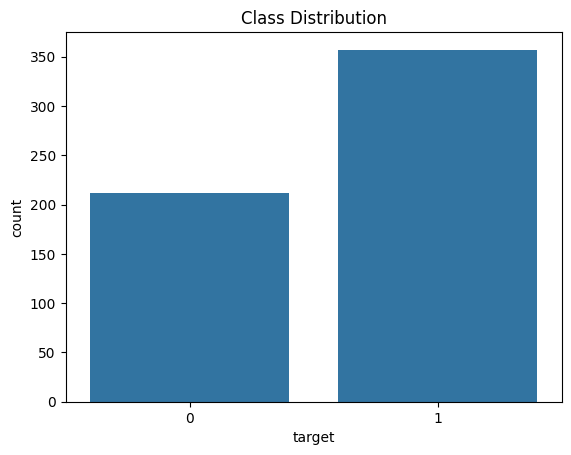

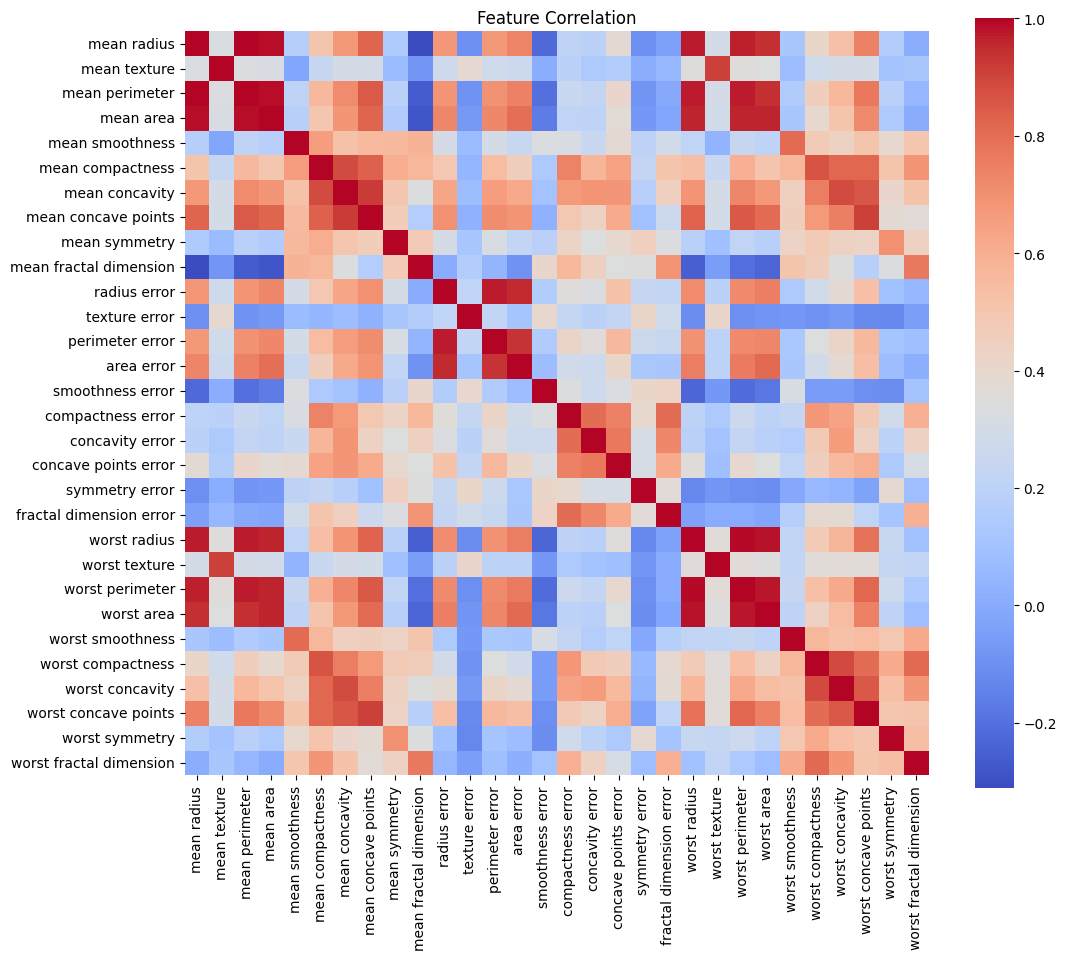

In [2]:
# 📊 資料視覺化
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap='coolwarm', square=True)
plt.title("Feature Correlation")
plt.show()

In [3]:
# 🔧 資料切分與前處理
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# ✅ 隨機森林
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'clf__max_depth': [None, 10, 20],
                         'clf__n_estimators': [50, 100]})

In [5]:
# ✅ 貝氏分類
from sklearn.naive_bayes import GaussianNB

pipe_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])

grid_nb = GridSearchCV(pipe_nb, param_grid={}, cv=5)
grid_nb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', GaussianNB())]),
             param_grid={})

In [6]:
# ✅ SVM
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC())
])

param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', SVC())]),
             param_grid={'clf__C': [0.1, 1, 10],
                         'clf__kernel': ['linear', 'rbf']})

In [7]:
# ✅ 集成學習
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('rf', grid_rf.best_estimator_),
    ('nb', grid_nb.best_estimator_),
    ('svm', grid_svm.best_estimator_)
], voting='hard')

voting.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('clf',
                                               RandomForestClassifier(random_state=42))])),
                             ('nb',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('clf', GaussianNB())])),
                             ('svm',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('clf',
                                               SVC(C=0.1, kernel='linear'))]))])

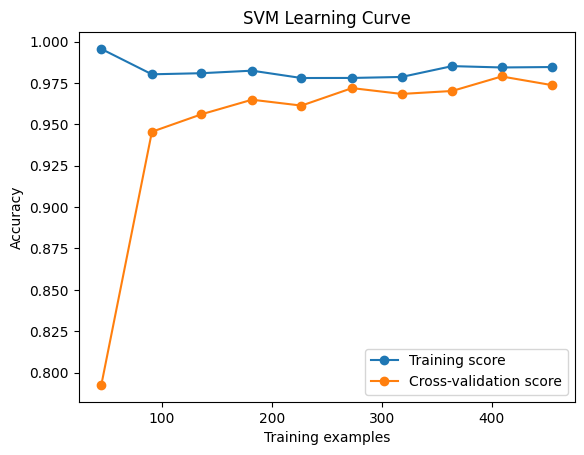

In [8]:
# 📈 學習曲線（以 SVM 為例）
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    grid_svm.best_estimator_, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, 'o-', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Cross-validation score')
plt.title("SVM Learning Curve")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



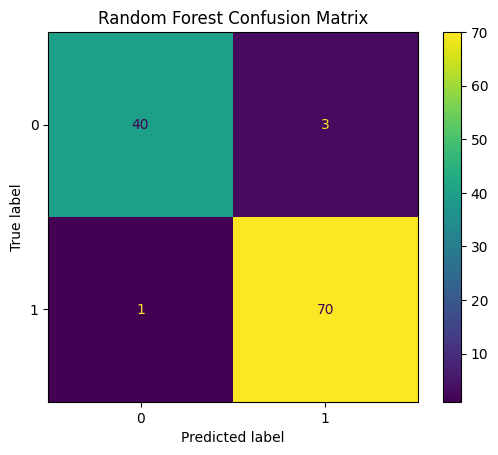


=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



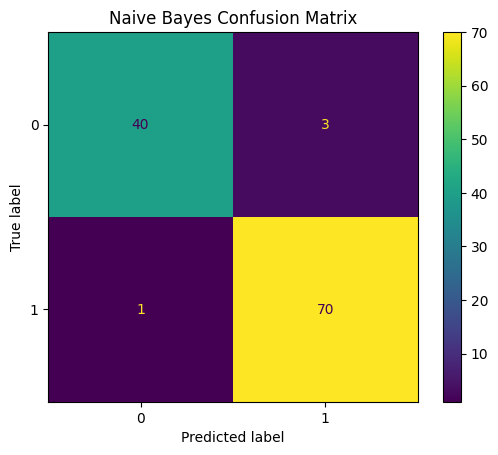


=== SVM ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



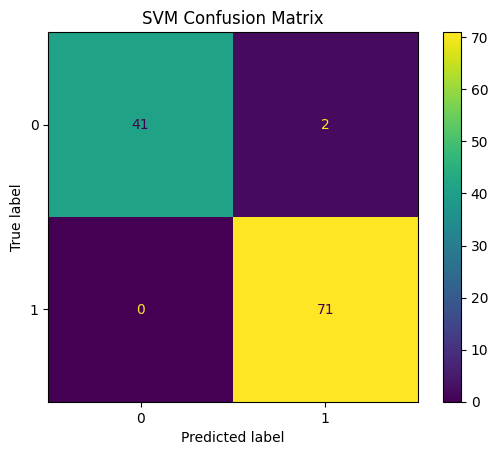


=== Voting Ensemble ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



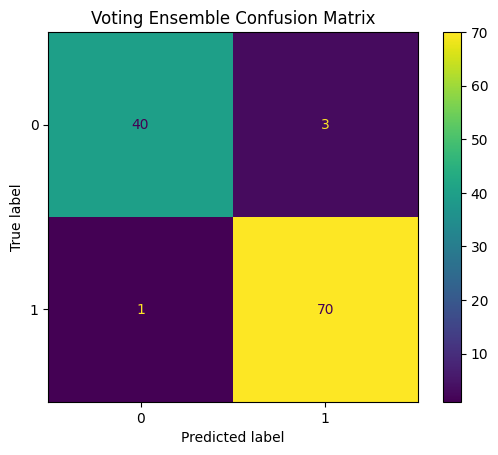

In [9]:
# 🧾 模型評估與混淆矩陣
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

evaluate_model("Random Forest", grid_rf)
evaluate_model("Naive Bayes", grid_nb)
evaluate_model("SVM", grid_svm)
evaluate_model("Voting Ensemble", voting)

In [10]:
# 📊 總結表格
from sklearn.metrics import accuracy_score

models = {
    'Random Forest': grid_rf,
    'Naive Bayes': grid_nb,
    'SVM': grid_svm,
    'Ensemble': voting
}

summary = pd.DataFrame([
    {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, mdl.predict(X_train)),
        'Test Accuracy': accuracy_score(y_test, mdl.predict(X_test))
    }
    for name, mdl in models.items()
])

summary

,Model,Train Accuracy,Test Accuracy
0,Random Forest,1.000000,0.964912
1,Naive Bayes,0.936264,0.964912
2,SVM,0.982418,0.982456
3,Ensemble,0.989011,0.964912
